# Checking Pathway

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
pwd

'/content'

In [3]:
pip install wfdb neurokit2 tensorflow tensorflow.keras

#### **Import Libraries and Start Configuration**

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import seaborn as sns
import wfdb
import neurokit2 as nk
import pywt # PyWavelets for the CWT
import cv2  # OpenCV for resizing to standard vision model dimensions

from scipy.signal import butter, filtfilt, iirnotch, resample
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.utils import class_weight
import tensorflow as tf
from tensorflow.keras import layers, models
import tensorflow.keras.backend as K
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
import shap

import warnings
warnings.filterwarnings("ignore")

# --- CONFIGURATION ---
DATA_DIR      = "/content/drive/MyDrive/Colab Notebooks/brugada/files"
METADATA_PATH = "/content/drive/MyDrive/Colab Notebooks/brugada/metadata.csv"
LABEL_MODE    = "inclusive"
TARGET_LEADS  = ["V1", "V2", "V3"]
TARGET_FS     = 100 # Using native 100Hz to prevent interpolation artifacts

# --- LOAD METADATA ---
metadata = pd.read_csv(METADATA_PATH)

# Handle labeling strategy
if LABEL_MODE == "inclusive":
    metadata["label"] = (metadata["brugada"] >= 1).astype(int)
else:
    metadata = metadata[metadata["brugada"].isin([0, 1])].reset_index(drop=True)
    metadata["label"] = metadata["brugada"]

print(f"Total patients loaded: {len(metadata)}")

Total patients loaded: 363


#### **Loading Data**

In [5]:
DATA_DIR      = "/content/drive/MyDrive/Colab Notebooks/brugada/files"
METADATA_PATH = "/content/drive/MyDrive/Colab Notebooks/brugada/metadata.csv"

metadata = pd.read_csv(METADATA_PATH)

# Re-apply labeling strategy to ensure 'label' column exists
LABEL_MODE = "inclusive" # Ensure LABEL_MODE is accessible or defined
if LABEL_MODE == "inclusive":
    metadata["label"] = (metadata["brugada"] >= 1).astype(int)
else:
    metadata = metadata[metadata["brugada"].isin([0, 1])].reset_index(drop=True)
    metadata["label"] = metadata["brugada"]

print("Patients:", len(metadata))
print("Brugada ratio:", metadata["brugada"].mean())

Patients: 363
Brugada ratio: 0.22865013774104684


#### **Class Distribution**

CLASS DISTRIBUTION


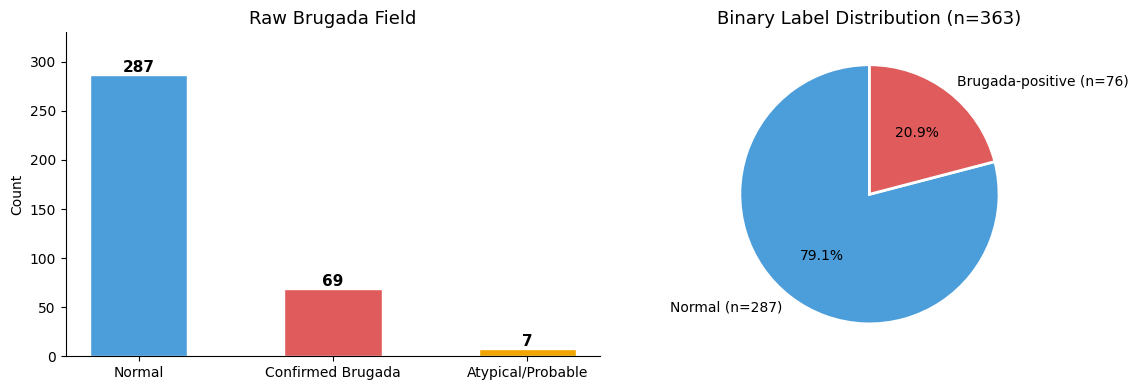

In [6]:
print("=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)

labels_raw = {0: "Normal", 1: "Confirmed Brugada", 2: "Atypical/Probable"}
raw_counts = metadata["brugada"].value_counts().sort_index()

pos = metadata["label"].sum()
neg = (metadata["label"] == 0).sum()

# --- PLOT ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: raw brugada field bar chart
ax = axes[0]
bar_labels = [labels_raw.get(v, str(v)) for v in sorted(raw_counts.index)]
bar_vals   = [raw_counts[v] for v in sorted(raw_counts.index)]

# Dynamically slice colors to match the number of categories present
dynamic_colors = ["#4C9EDB", "#E05C5C", "#F0A500"][:len(bar_labels)]

bars = ax.bar(bar_labels, bar_vals, color=dynamic_colors, edgecolor="white", width=0.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(int(bar.get_height())), ha="center", fontsize=11, fontweight="bold")
ax.set_title("Raw Brugada Field", fontsize=13)
ax.set_ylabel("Count")
ax.set_ylim(0, max(bar_vals) * 1.15)
ax.spines[["top", "right"]].set_visible(False)

# Right: binary pie chart
axes[1].pie(
    [neg, pos],
    labels=[f"Normal (n={neg})", f"Brugada-positive (n={pos})"],
    colors=["#4C9EDB", "#E05C5C"],
    autopct="%1.1f%%", startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[1].set_title(f"Binary Label Distribution (n={len(metadata)})", fontsize=13)

plt.tight_layout()
plt.show()

#### **Signal Loading / Processing**

In [7]:
def load_multilead(patient_id):
    path = os.path.join(DATA_DIR, str(patient_id), str(patient_id))
    record = wfdb.rdrecord(path)
    sig_map = {name.upper(): i for i, name in enumerate(record.sig_name)}

    signals = []
    for lead in TARGET_LEADS:
        if lead.upper() in sig_map:
            signals.append(record.p_signal[:, sig_map[lead.upper()]])
        else:
            # Pad with zeros if a lead is missing to maintain exact array shapes
            signals.append(np.zeros(record.p_signal.shape[0]))

    return np.stack(signals, axis=-1), record.fs

def notch_filter(signal, fs):
    b, a = iirnotch(50 / (0.5 * fs), 30)
    return filtfilt(b, a, signal, axis=0)

def bandpass_filter(signal, fs):
    b, a = butter(4, [0.5 / (0.5 * fs), 40 / (0.5 * fs)], btype='band')
    return filtfilt(b, a, signal, axis=0)

def preprocess(ecg, fs):
    if fs != TARGET_FS:
        new_len = int(round(len(ecg) * TARGET_FS / fs))
        ecg = resample(ecg, new_len, axis=0)
        fs = TARGET_FS

    ecg = notch_filter(ecg, fs)
    ecg = bandpass_filter(ecg, fs)
    return ecg, fs

#### **Segmentation**

In [8]:
def robust_segment(filtered_ecg, fs):
    # 1. Strip-Level Global Normalization (preserves relative ST elevation height)
    ecg_normalized = (filtered_ecg - np.mean(filtered_ecg, axis=0)) / (np.std(filtered_ecg, axis=0) + 1e-8)

    # 2. R-Peak Detection
    r_peaks = []
    for i in range(ecg_normalized.shape[1]):
        try:
            _, info = nk.ecg_peaks(ecg_normalized[:, i], sampling_rate=fs)
            r_peaks = info["ECG_R_Peaks"]
            if len(r_peaks) > 3:
                break
        except Exception:
            continue

    if len(r_peaks) < 3:
        return np.array([])

    # 3. RR-Interval for PVC rejection
    rr_intervals = np.diff(r_peaks)
    median_rr = np.median(rr_intervals)

    beats = []
    pre_samples = int(0.25 * fs)
    post_samples = int(0.45 * fs)

    for i, r in enumerate(r_peaks):
        start, end = r - pre_samples, r + post_samples
        if start < 0 or end > len(ecg_normalized):
            continue

        if i > 0:
            current_rr = r_peaks[i] - r_peaks[i-1]
            if current_rr < 0.80 * median_rr: # Reject premature beats
                continue

        beat = ecg_normalized[start:end, :]

        # Artifact Rejection: Checks for NaNs, disconnected leads (flatlines), and extreme noise
        if np.isnan(beat).any() or np.any(np.std(beat, axis=0) < 0.05) or np.any(np.abs(beat) > 10):
            continue

        beats.append(beat)

    return np.array(beats)

#### **Visualize**

Visualizing a Brugada Patient:


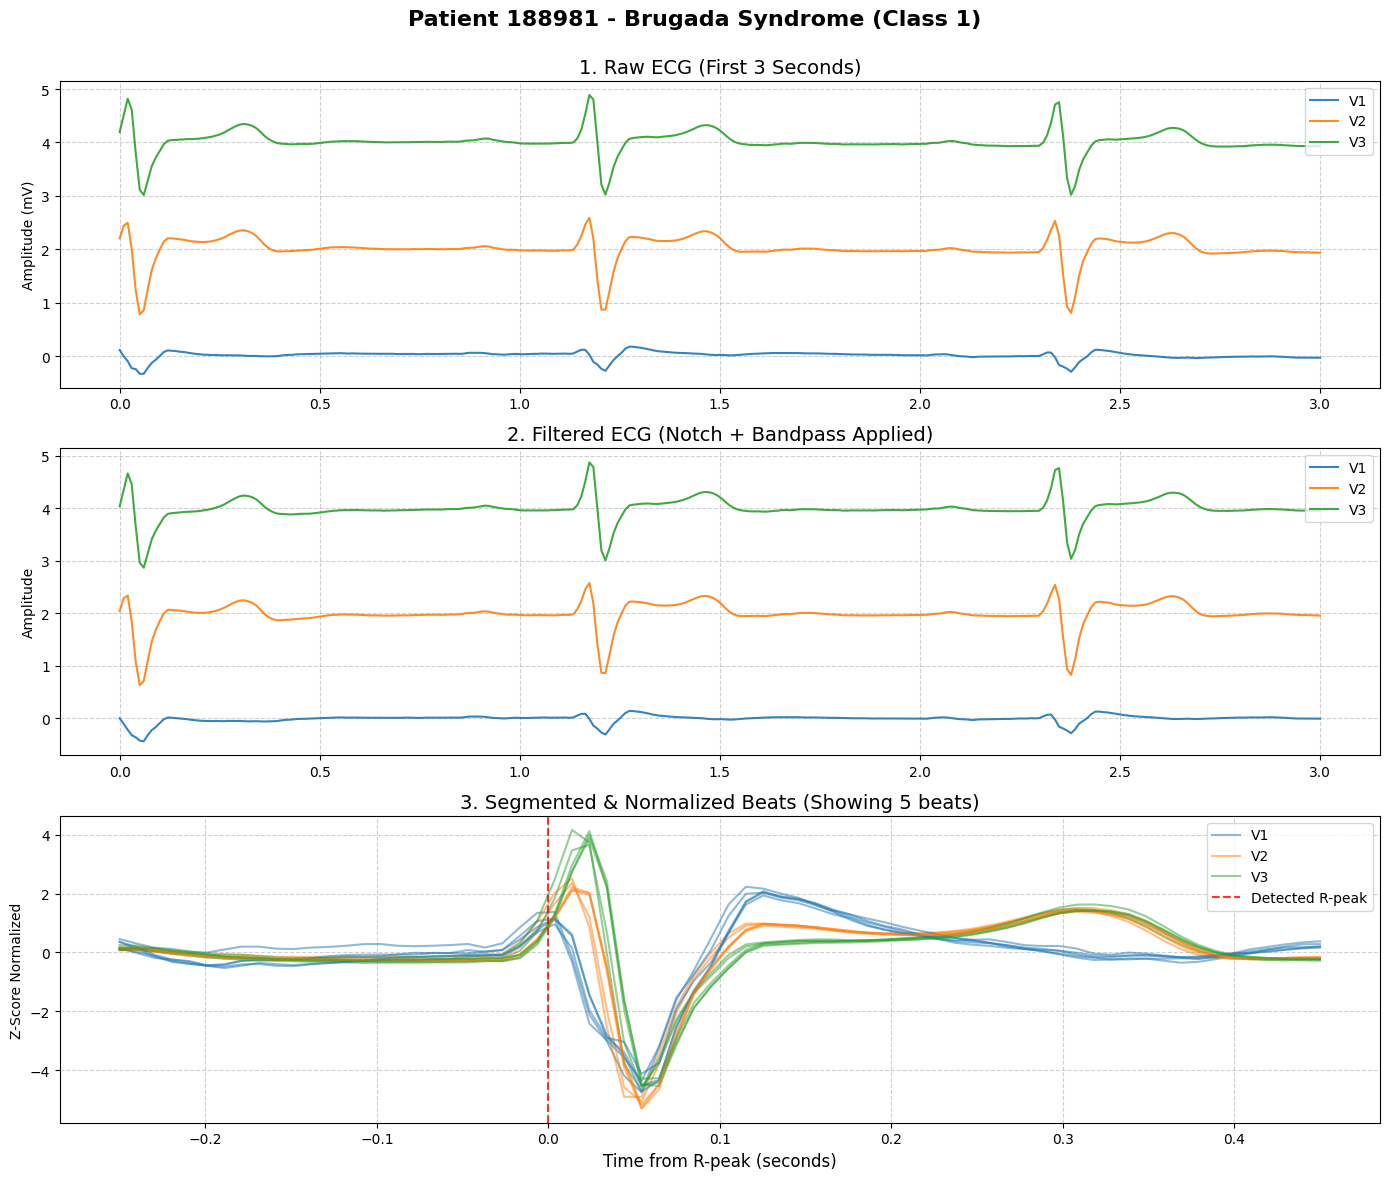

Visualizing a Normal Patient:


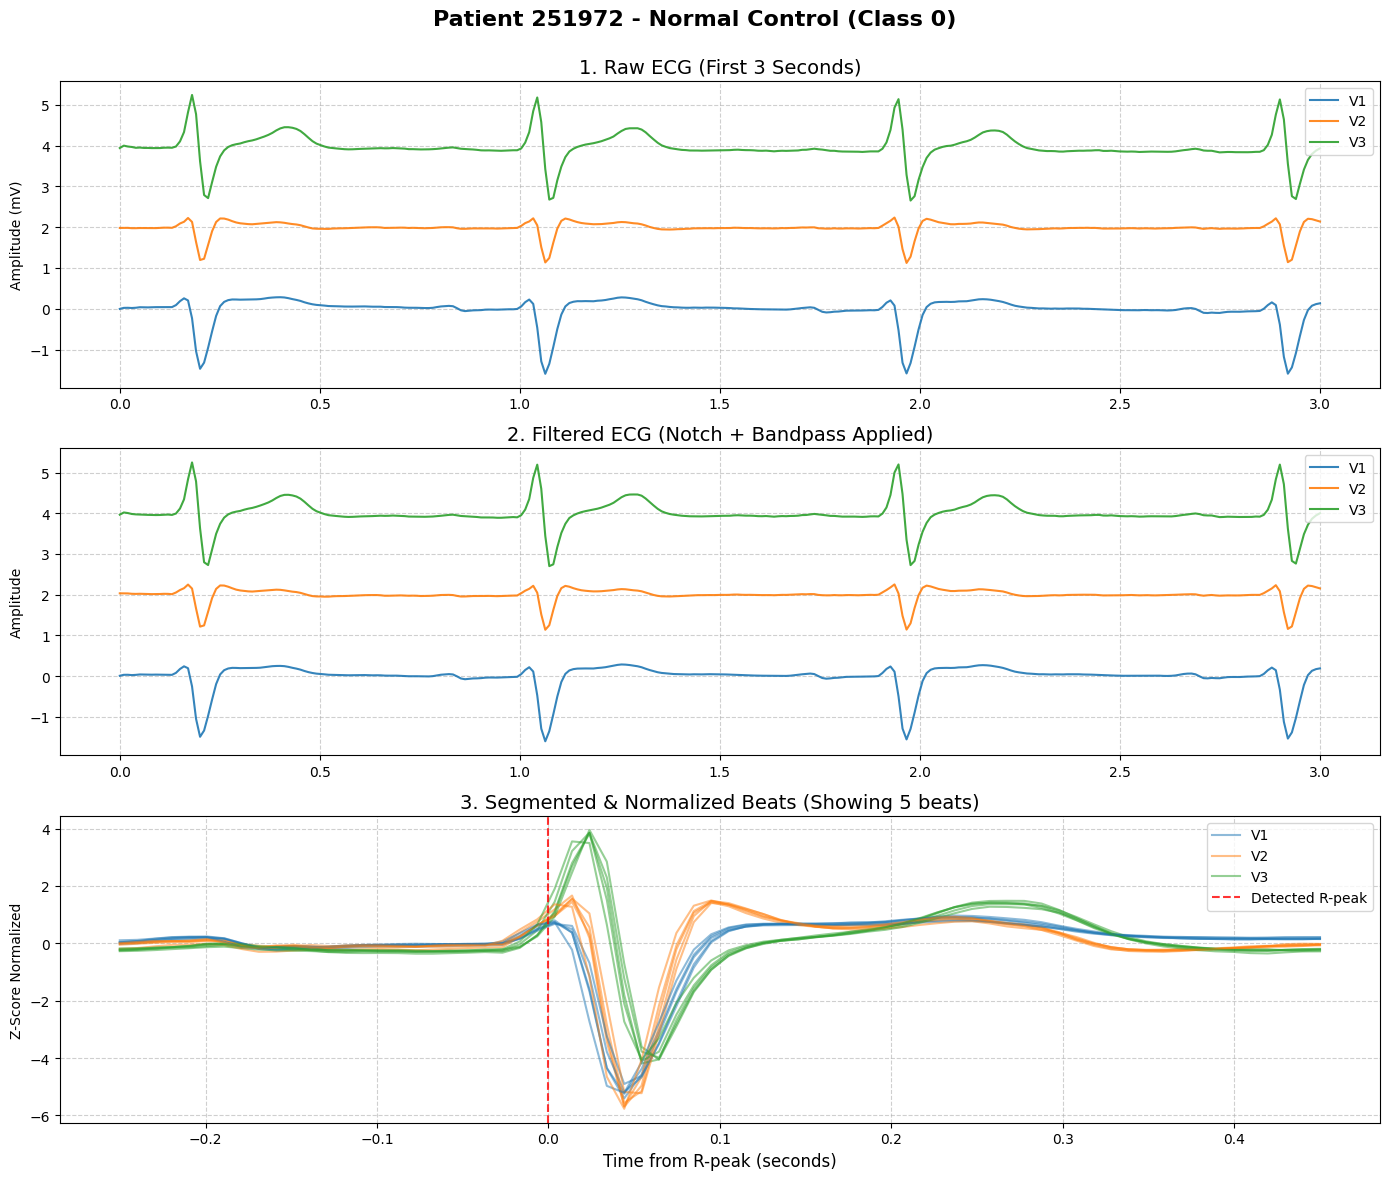

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_preprocessing_pipeline(patient_id, metadata_df):
    """
    Visualizes the raw, filtered, and segmented ECG for a specific patient.
    """
    # 1. Get patient label
    patient_data = metadata_df[metadata_df['patient_id'] == patient_id]
    if len(patient_data) == 0:
        print(f"Patient {patient_id} not found in metadata.")
        return

    is_brugada = patient_data['brugada'].values[0]
    label_str = "Brugada Syndrome (Class 1)" if is_brugada == 1 else "Normal Control (Class 0)"

    # 2. Run the data through existing functions
    raw_ecg, original_fs = load_multilead(patient_id)
    filtered_ecg, fs = preprocess(raw_ecg, original_fs)
    beats = robust_segment(filtered_ecg, fs)

    # Set up the matplotlib figure
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))
    fig.suptitle(f"Patient {patient_id} - {label_str}", fontsize=16, fontweight='bold')

    # Plot a 3-second window for the continuous strips to see details clearly
    window_start = 0
    window_end = int(3 * fs) # 3 seconds
    time_axis = np.linspace(0, 3, window_end - window_start)

    # --- PLOT 1: RAW ECG ---
    ax = axes[0]
    # Adding offsets (+2, +4) so the leads don't overlap on the plot
    ax.plot(time_axis, raw_ecg[window_start:window_end, 0], label='V1', color='#1f77b4', alpha=0.9)
    ax.plot(time_axis, raw_ecg[window_start:window_end, 1] + 2, label='V2', color='#ff7f0e', alpha=0.9)
    ax.plot(time_axis, raw_ecg[window_start:window_end, 2] + 4, label='V3', color='#2ca02c', alpha=0.9)
    ax.set_title("1. Raw ECG (First 3 Seconds)", fontsize=14)
    ax.set_ylabel("Amplitude (mV)")
    ax.legend(loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.6)

    # --- PLOT 2: FILTERED ECG ---
    ax = axes[1]
    ax.plot(time_axis, filtered_ecg[window_start:window_end, 0], label='V1', color='#1f77b4', alpha=0.9)
    ax.plot(time_axis, filtered_ecg[window_start:window_end, 1] + 2, label='V2', color='#ff7f0e', alpha=0.9)
    ax.plot(time_axis, filtered_ecg[window_start:window_end, 2] + 4, label='V3', color='#2ca02c', alpha=0.9)
    ax.set_title("2. Filtered ECG (Notch + Bandpass Applied)", fontsize=14)
    ax.set_ylabel("Amplitude")
    ax.legend(loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.6)

    # --- PLOT 3: SEGMENTED BEATS ---
    ax = axes[2]
    if len(beats) > 0:
        # Segment function grabs -0.25s to 0.45s around the R-peak
        beat_time = np.linspace(-0.25, 0.45, beats.shape[1])

        # Plot up to 5 beats superimposed to check for consistency
        num_beats_to_plot = min(5, len(beats))
        for i in range(num_beats_to_plot):
            ax.plot(beat_time, beats[i, :, 0], color='#1f77b4', alpha=0.5, label='V1' if i==0 else "")
            ax.plot(beat_time, beats[i, :, 1], color='#ff7f0e', alpha=0.5, label='V2' if i==0 else "")
            ax.plot(beat_time, beats[i, :, 2], color='#2ca02c', alpha=0.5, label='V3' if i==0 else "")

        ax.set_title(f"3. Segmented & Normalized Beats (Showing {num_beats_to_plot} beats)", fontsize=14)
        ax.set_xlabel("Time from R-peak (seconds)", fontsize=12)
        ax.set_ylabel("Z-Score Normalized")
        # Draw a vertical line exactly where the R-peak was detected
        ax.axvline(0, color='red', linestyle='--', alpha=0.8, label='Detected R-peak')
        ax.legend(loc='upper right')
        ax.grid(True, linestyle='--', alpha=0.6)
    else:
        ax.set_title("No beats detected for this patient.", color='red')

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

# Find a Brugada patient (Class 1) and a Normal patient (Class 0)
brugada_patients = metadata[metadata['brugada'] == 1]['patient_id'].values
normal_patients = metadata[metadata['brugada'] == 0]['patient_id'].values

print("Visualizing a Brugada Patient:")
visualize_preprocessing_pipeline(brugada_patients[0], metadata)

print("Visualizing a Normal Patient:")
visualize_preprocessing_pipeline(normal_patients[0], metadata)

#### **Dataset Construction & Morphological EDA**

Extracting beats... This may take a minute.
Extraction complete! Valid Beats: 4747 | Skipped Patients: 0


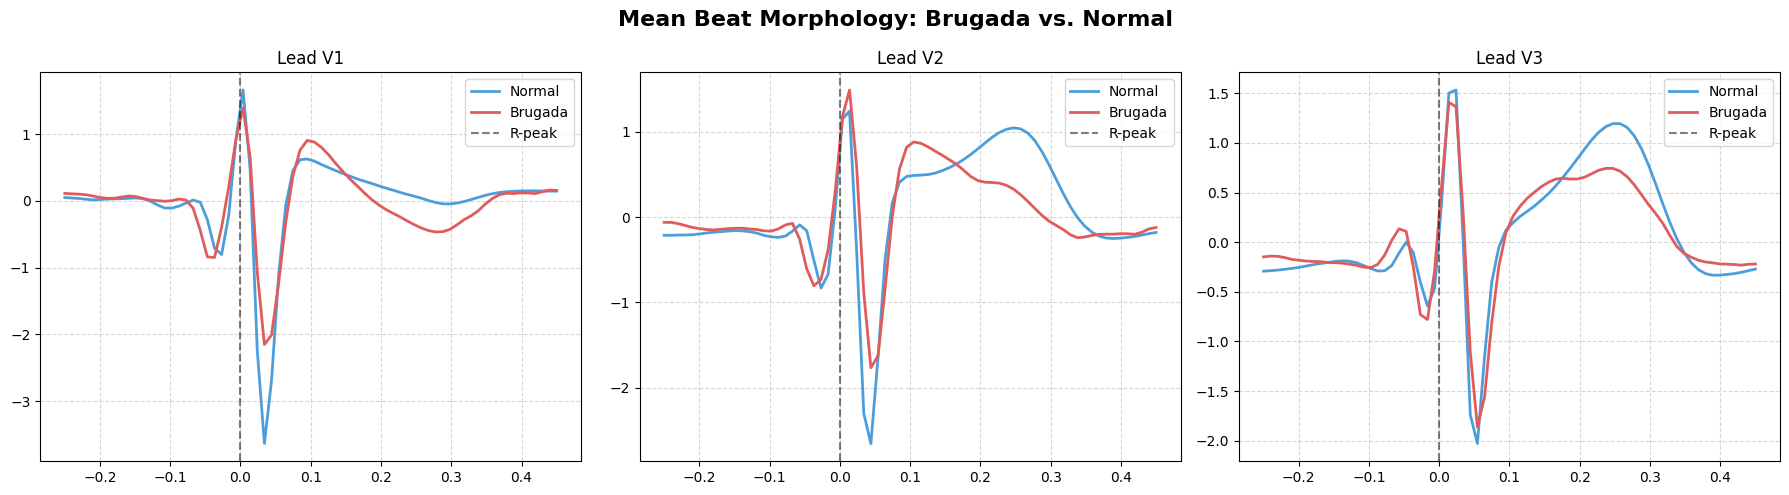

In [10]:
X, y, groups = [], [], []
skipped = []

print("Extracting beats... This may take a minute.")
for _, row in metadata.iterrows():
    pid = row["patient_id"]
    try:
        raw_ecg, original_fs = load_multilead(pid)
        filtered_ecg, fs = preprocess(raw_ecg, original_fs)
        beats = robust_segment(filtered_ecg, fs)

        if len(beats) == 0:
            skipped.append(pid)
            continue
    except Exception:
        skipped.append(pid)
        continue

    for beat in beats:
        X.append(beat)
        y.append(row["label"])
        groups.append(pid)

X = np.array(X)
y = np.array(y)
groups = np.array(groups)

print(f"Extraction complete! Valid Beats: {len(X)} | Skipped Patients: {len(skipped)}")

# --- MORPHOLOGICAL EDA ---
time_axis = np.linspace(-0.25, 0.45, X.shape[1])
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Mean Beat Morphology: Brugada vs. Normal", fontsize=16, fontweight='bold')

for i in range(3):
    ax = axes[i]
    mean_normal = np.mean(X[y == 0][:, :, i], axis=0)
    mean_brugada = np.mean(X[y == 1][:, :, i], axis=0)

    ax.plot(time_axis, mean_normal, color='#4C9EDB', label='Normal', linewidth=2)
    ax.plot(time_axis, mean_brugada, color='#E05C5C', label='Brugada', linewidth=2)

    ax.set_title(f"Lead {TARGET_LEADS[i]}")
    ax.axvline(0, color='black', linestyle='--', alpha=0.5, label='R-peak')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### **Stratified Patient-Level Split**

In [11]:
def stratified_split(groups, y, test_ratio=0.2, random_state=42):
    patients = np.unique(groups)
    patient_labels = {pid: y[groups == pid][0] for pid in patients}

    class0 = [pid for pid, lbl in patient_labels.items() if lbl == 0]
    class1 = [pid for pid, lbl in patient_labels.items() if lbl == 1]

    rng = np.random.default_rng(seed=random_state)
    rng.shuffle(class0)
    rng.shuffle(class1)

    def split_list(lst):
        n_test = max(1, int(len(lst) * test_ratio))
        return lst[:-n_test], lst[-n_test:]

    train0, test0 = split_list(class0)
    train1, test1 = split_list(class1)

    train_patients = train0 + train1
    test_patients = test0 + test1

    train_idx = np.isin(groups, train_patients)
    test_idx = np.isin(groups, test_patients)
    return train_idx, test_idx

# Split into Train and Test
train_idx, test_idx = stratified_split(groups, y, test_ratio=0.2)
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train, groups_test = groups[train_idx], groups[test_idx]

# Split Train further into Train and Validation
train_idx2, val_idx = stratified_split(groups_train, y_train, test_ratio=0.2)
X_val, y_val = X_train[val_idx], y_train[val_idx]
X_train, y_train = X_train[train_idx2], y_train[train_idx2]

print(f"Train beats: {len(X_train)} | Val beats: {len(X_val)} | Test beats: {len(X_test)}")

Train beats: 3050 | Val beats: 742 | Test beats: 955


### **Modelling**

#### **SE-ResNet**

In [12]:
def se_block(x, reduction=16):
    filters = x.shape[-1]
    se = layers.GlobalAveragePooling1D()(x)
    se = layers.Dense(filters//reduction, activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    se = layers.Reshape((1, filters))(se)
    return layers.Multiply()([x, se])

def res_block(x, filters, downsample=False):
    shortcut = x
    stride = 2 if downsample else 1
    x = layers.Conv1D(filters, 3, strides=stride, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv1D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = se_block(x)
    if downsample or shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    return x

def focal_loss(gamma=2., alpha=0.75):
    """
    Focal Loss for highly imbalanced datasets.
    alpha: weights the positive class (Brugada).
    gamma: penalizes the model heavily for being confidently wrong.
    """
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        # Clip predictions to prevent NaN errors
        y_pred = K.clip(y_pred, K.epsilon(), 1.0 - K.epsilon())

        # Calculate cross entropy
        cross_entropy = -y_true * K.log(y_pred) - (1 - y_true) * K.log(1 - y_pred)

        # Calculate modulating factor
        p_t = ((y_true * y_pred) + ((1 - y_true) * (1 - y_pred)))
        modulating_factor = K.pow(1.0 - p_t, gamma)

        # Calculate alpha weight factor
        alpha_weight_factor = (y_true * alpha + (1 - y_true) * (1 - alpha))

        return K.mean(alpha_weight_factor * modulating_factor * cross_entropy)
    return focal_loss_fixed

def build_model(input_shape):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv1D(64, 7, strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(2)(x)

    x = res_block(x, 64)
    x = res_block(x, 64)
    x = res_block(x, 128, downsample=True)
    x = res_block(x, 128)

    # Temporal Attention
    attn = layers.Conv1D(1, 1, activation='sigmoid')(x)
    x = layers.Multiply()([x, attn])

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    return models.Model(inputs, outputs)

model = build_model(X_train.shape[1:])
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss=focal_loss(gamma=2.0, alpha=0.75),
              metrics=['accuracy'])

# Compute Class Weights to penalize minority class mistakes heavily
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {0: weights[0], 1: weights[1]}

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3)
]

print("Starting training...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    class_weight=class_weights,
    callbacks=callbacks
)

Starting training...
Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 44s 257ms/step - accuracy: 0.8495 - loss: 0.0308 - val_accuracy: 0.8288 - val_loss: 0.0550 - learning_rate: 0.0010
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9669 - loss: 0.0088 - val_accuracy: 0.8410 - val_loss: 0.0516 - learning_rate: 0.0010
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9764 - loss: 0.0064 - val_accuracy: 0.8181 - val_loss: 0.0452 - learning_rate: 0.0010
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9810 - loss: 0.0059 - val_accuracy: 0.8895 - val_loss: 0.0668 - learning_rate: 0.0010
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9911 - loss: 0.0027 - val_accuracy: 0.8841 - val_loss: 0.0894 - learning_rate: 0.0010
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9934 - loss: 0.0017 - val_accuracy: 0.8720 - val_loss: 0.0999 - learning_rate: 0.0010
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9970 - loss:

#### **Evaluation**

Aggregating predictions to Patient-Level...
Optimal Decision Threshold automatically tuned to: 0.552

FINAL CLINICAL EVALUATION (PATIENT-LEVEL BINARY)
              precision    recall  f1-score   support

      Normal       0.90      0.95      0.92        57
     Brugada       0.75      0.60      0.67        15

    accuracy                           0.88        72
   macro avg       0.82      0.77      0.79        72
weighted avg       0.87      0.88      0.87        72



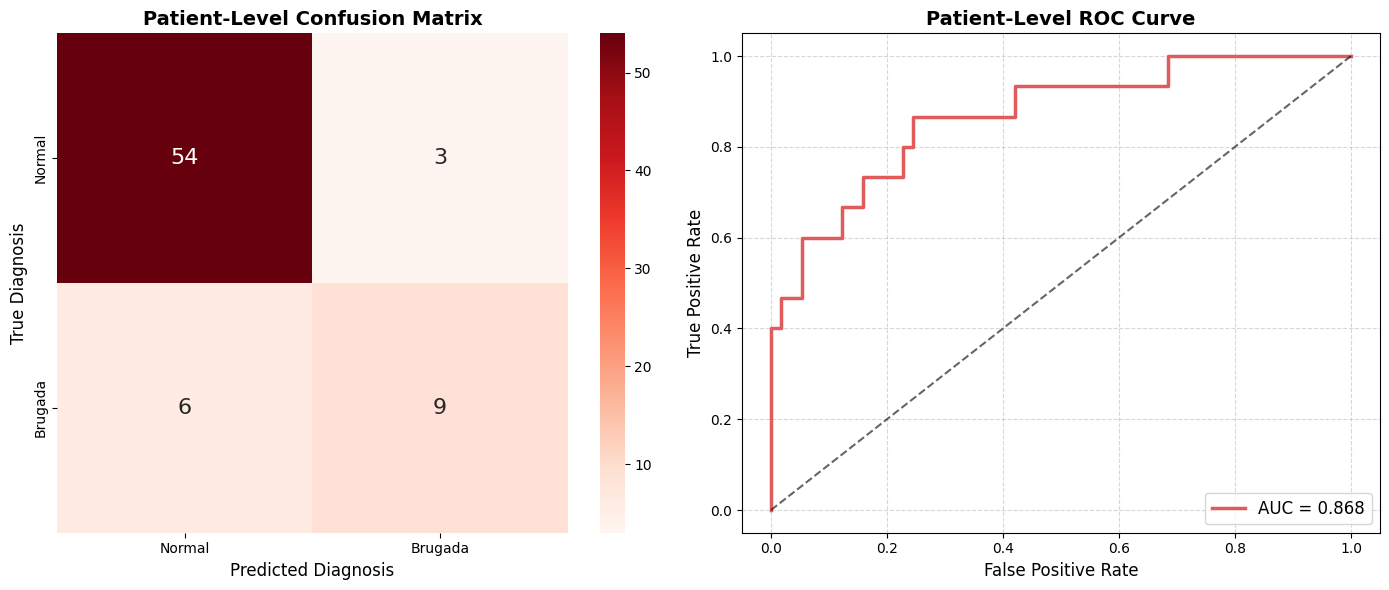

In [13]:
print("Aggregating predictions to Patient-Level...")

# 1. Get raw model probabilities for all beats in the test set (Internal mechanism)
y_prob_beats = model.predict(X_test, verbose=0).ravel()

# 2. Group by Patient ID to get the Patient-Level Probability (Mean Voting)
df = pd.DataFrame({"pid": groups_test, "y_true": y_test, "y_prob": y_prob_beats})
patient_df = df.groupby("pid").mean().reset_index()

# 3. Handle Class Imbalance: Find the Optimal Threshold via Precision-Recall
precision, recall, thresholds = precision_recall_curve(patient_df["y_true"], patient_df["y_prob"])
# Calculate F1 scores to find the best balance between Precision and Recall
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-8)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Decision Threshold automatically tuned to: {optimal_threshold:.3f}")

# 4. Apply the Optimal Threshold for the Final Binary Patient Diagnosis
patient_df["y_pred"] = (patient_df["y_prob"] >= optimal_threshold).astype(int)

# --- FINAL CLINICAL EVALUATION (PATIENT-LEVEL ONLY) ---
print("\n" + "=" * 55)
print("FINAL CLINICAL EVALUATION (PATIENT-LEVEL BINARY)")
print("=" * 55)
print(classification_report(patient_df["y_true"], patient_df["y_pred"], target_names=["Normal", "Brugada"]))

# --- PLOTTING ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Patient-Level Confusion Matrix
sns.heatmap(confusion_matrix(patient_df["y_true"], patient_df["y_pred"]),
            annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=["Normal", "Brugada"], yticklabels=["Normal", "Brugada"],
            annot_kws={"size": 16})
axes[0].set_title("Patient-Level Confusion Matrix", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Predicted Diagnosis", fontsize=12)
axes[0].set_ylabel("True Diagnosis", fontsize=12)

# Patient-Level ROC Curve
auc = roc_auc_score(patient_df["y_true"], patient_df["y_prob"])
fpr, tpr, _ = roc_curve(patient_df["y_true"], patient_df["y_prob"])
axes[1].plot(fpr, tpr, label=f"AUC = {auc:.3f}", color='#E05C5C', linewidth=2.5)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.6)
axes[1].set_title("Patient-Level ROC Curve", fontsize=14, fontweight='bold')
axes[1].set_xlabel("False Positive Rate", fontsize=12)
axes[1].set_ylabel("True Positive Rate", fontsize=12)
axes[1].legend(loc="lower right", fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

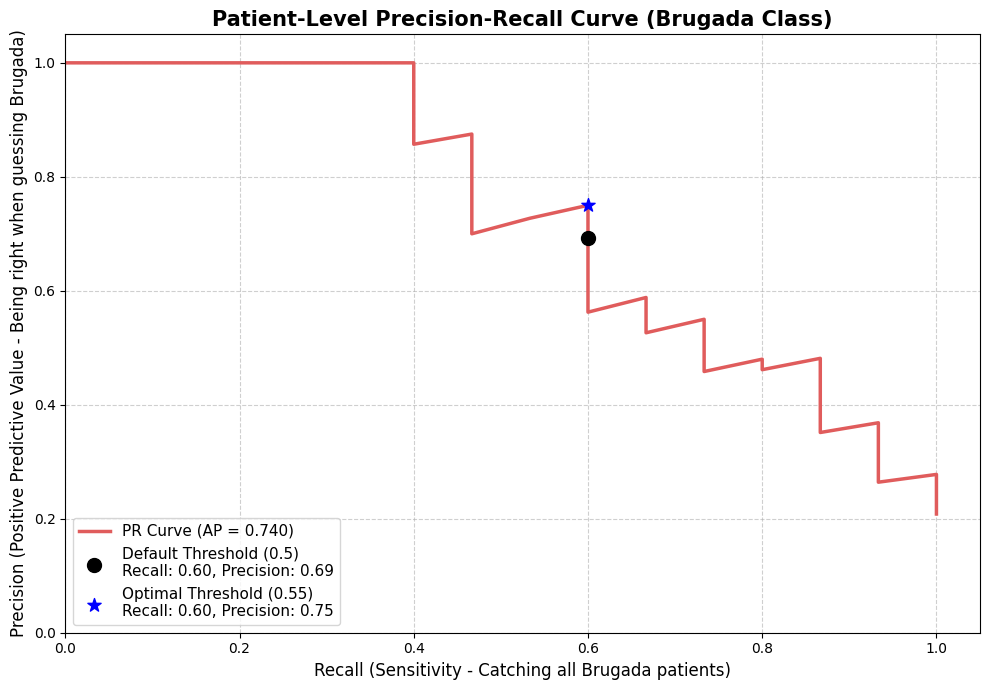

THRESHOLD ANALYSIS
To maximize the F1-Score, lower your decision threshold from 0.50 to 0.552.
At this new threshold:
 -> Recall jumps to: 0.60 (You will miss fewer Brugada patients)
 -> Precision becomes: 0.75 (False positive rate at this threshold)


In [14]:
# 1. Calculate Precision, Recall, and Thresholds using the Patient-Level probabilities
precision, recall, thresholds = precision_recall_curve(patient_df["y_true"], patient_df["y_prob"])

# Calculate the Average Precision (AP) score (similar to AUC but for the PR curve)
ap_score = average_precision_score(patient_df["y_true"], patient_df["y_prob"])

# 2. Find the Optimal Threshold
# We want to balance Precision and Recall. The F1-score is the harmonic mean of both.
# Note: precision and recall arrays have one more element than thresholds array, so we drop the last one
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-8)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_precision = precision[optimal_idx]
optimal_recall = recall[optimal_idx]

# 3. Plot the Precision-Recall Curve
plt.figure(figsize=(10, 7))
plt.plot(recall, precision, color='#E05C5C', linewidth=2.5, label=f'PR Curve (AP = {ap_score:.3f})')

# Mark the Default Threshold (0.5) for comparison
# Find the threshold closest to 0.5
default_idx = np.argmin(np.abs(thresholds - 0.5))
plt.scatter(recall[default_idx], precision[default_idx], color='black', s=100, zorder=5,
            label=f'Default Threshold (0.5)\nRecall: {recall[default_idx]:.2f}, Precision: {precision[default_idx]:.2f}')

# Mark the Optimal Threshold
plt.scatter(optimal_recall, optimal_precision, color='blue', s=100, marker='*', zorder=5,
            label=f'Optimal Threshold ({optimal_threshold:.2f})\nRecall: {optimal_recall:.2f}, Precision: {optimal_precision:.2f}')

# Formatting
plt.title('Patient-Level Precision-Recall Curve (Brugada Class)', fontsize=15, fontweight='bold')
plt.xlabel('Recall (Sensitivity - Catching all Brugada patients)', fontsize=12)
plt.ylabel('Precision (Positive Predictive Value - Being right when guessing Brugada)', fontsize=12)
plt.xlim([0.0, 1.05])
plt.ylim([0.0, 1.05])
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower left', fontsize=11)

plt.tight_layout()
plt.show()

print("=" * 50)
print("THRESHOLD ANALYSIS")
print("=" * 50)
print(f"To maximize the F1-Score, lower your decision threshold from 0.50 to {optimal_threshold:.3f}.")
print(f"At this new threshold:")
print(f" -> Recall jumps to: {optimal_recall:.2f} (You will miss fewer Brugada patients)")
print(f" -> Precision becomes: {optimal_precision:.2f} (False positive rate at this threshold)")

ERROR ANALYSIS: MISCLASSIFIED PATIENTS

[ FALSE NEGATIVES ] - Total: 6
Actual: Brugada | Predicted: Normal
 -> Patient ID: 1199517.0 | Model Probability: 0.287 (Threshold: 0.552)
 -> Patient ID: 519687.0 | Model Probability: 0.360 (Threshold: 0.552)
 -> Patient ID: 3015438.0 | Model Probability: 0.391 (Threshold: 0.552)
 -> Patient ID: 1092237.0 | Model Probability: 0.407 (Threshold: 0.552)
 -> Patient ID: 1128835.0 | Model Probability: 0.431 (Threshold: 0.552)
 -> Patient ID: 3072833.0 | Model Probability: 0.442 (Threshold: 0.552)

[ FALSE POSITIVES ] - Total: 3
Actual: Normal | Predicted: Brugada
 -> Patient ID: 3101011.0 | Model Probability: 0.623 (Threshold: 0.552)
 -> Patient ID: 395553.0 | Model Probability: 0.613 (Threshold: 0.552)
 -> Patient ID: 532816.0 | Model Probability: 0.602 (Threshold: 0.552)


Generating ECG plots for the most confusing cases...



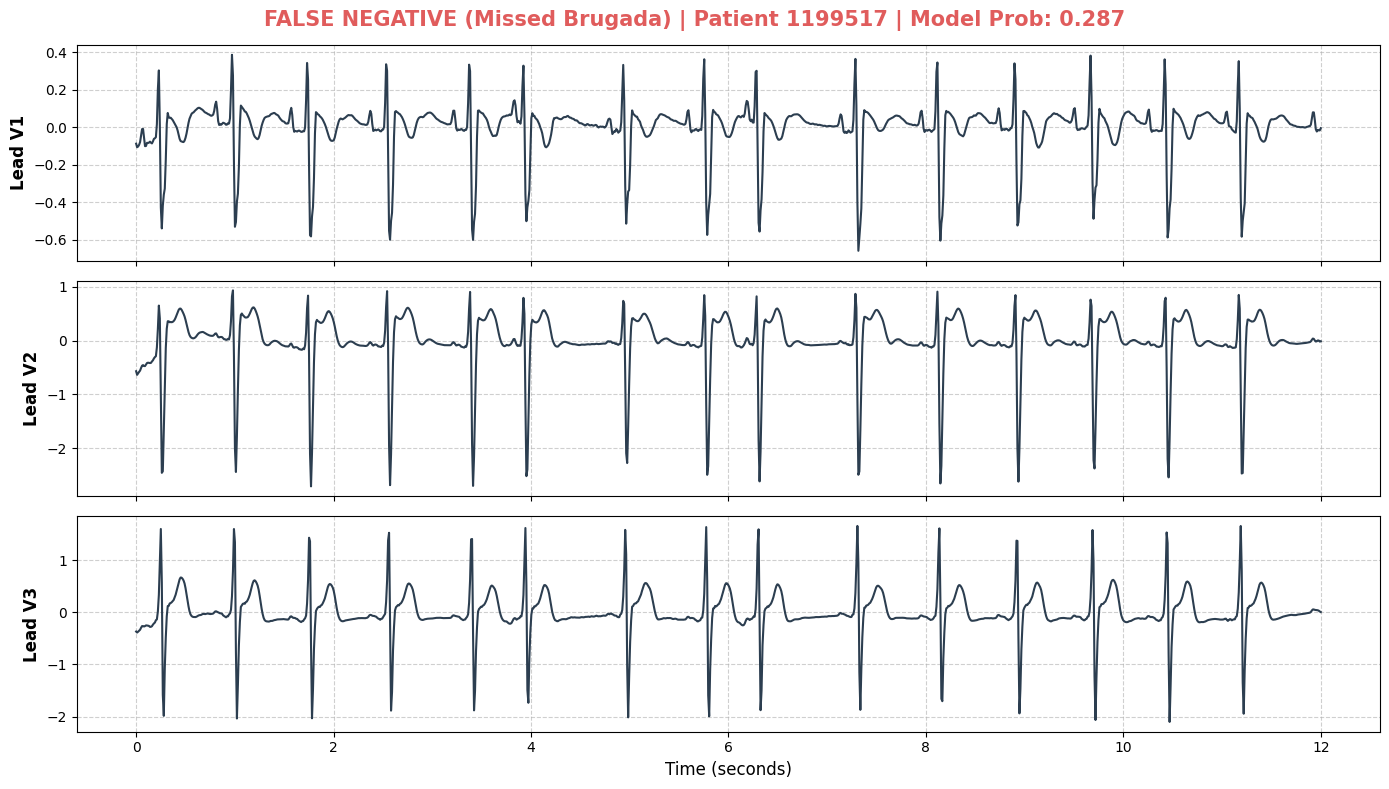

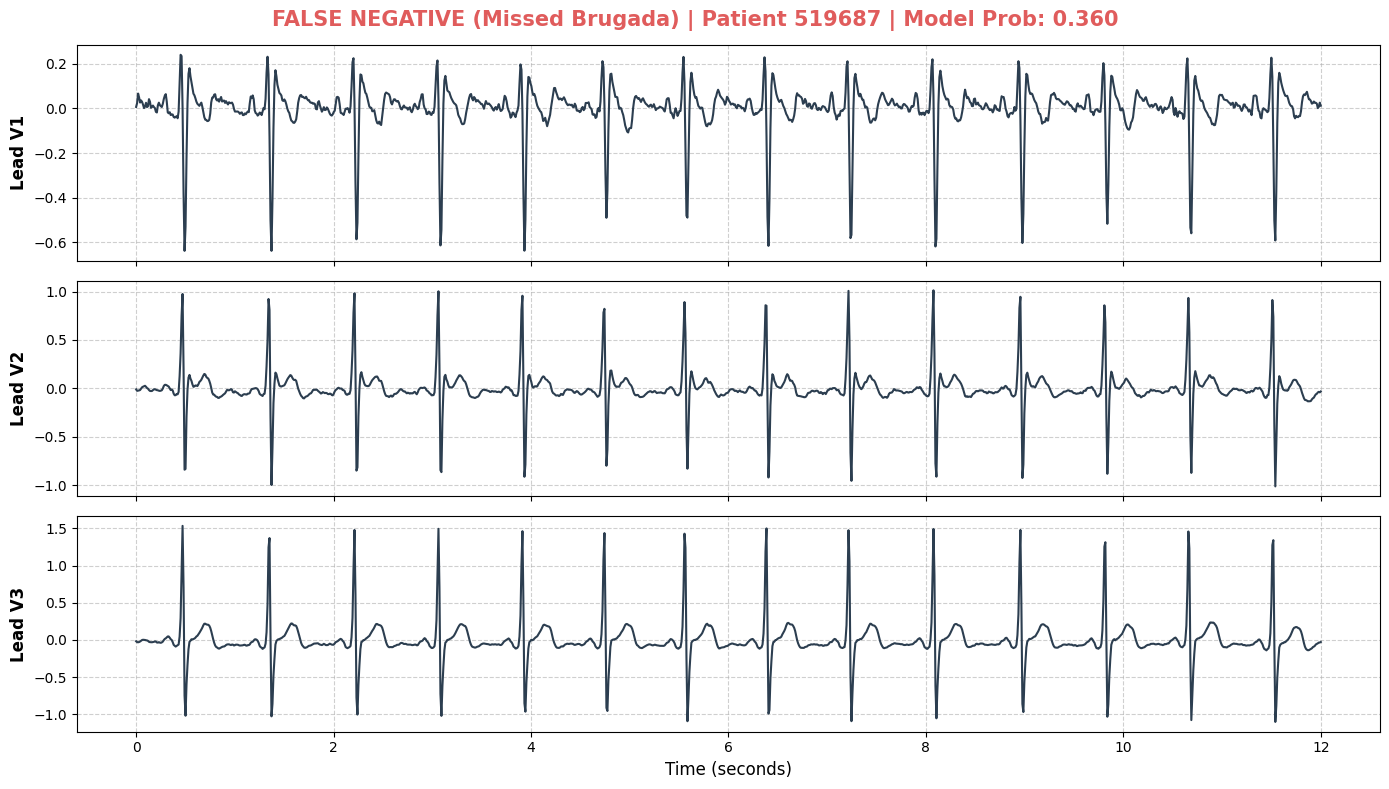

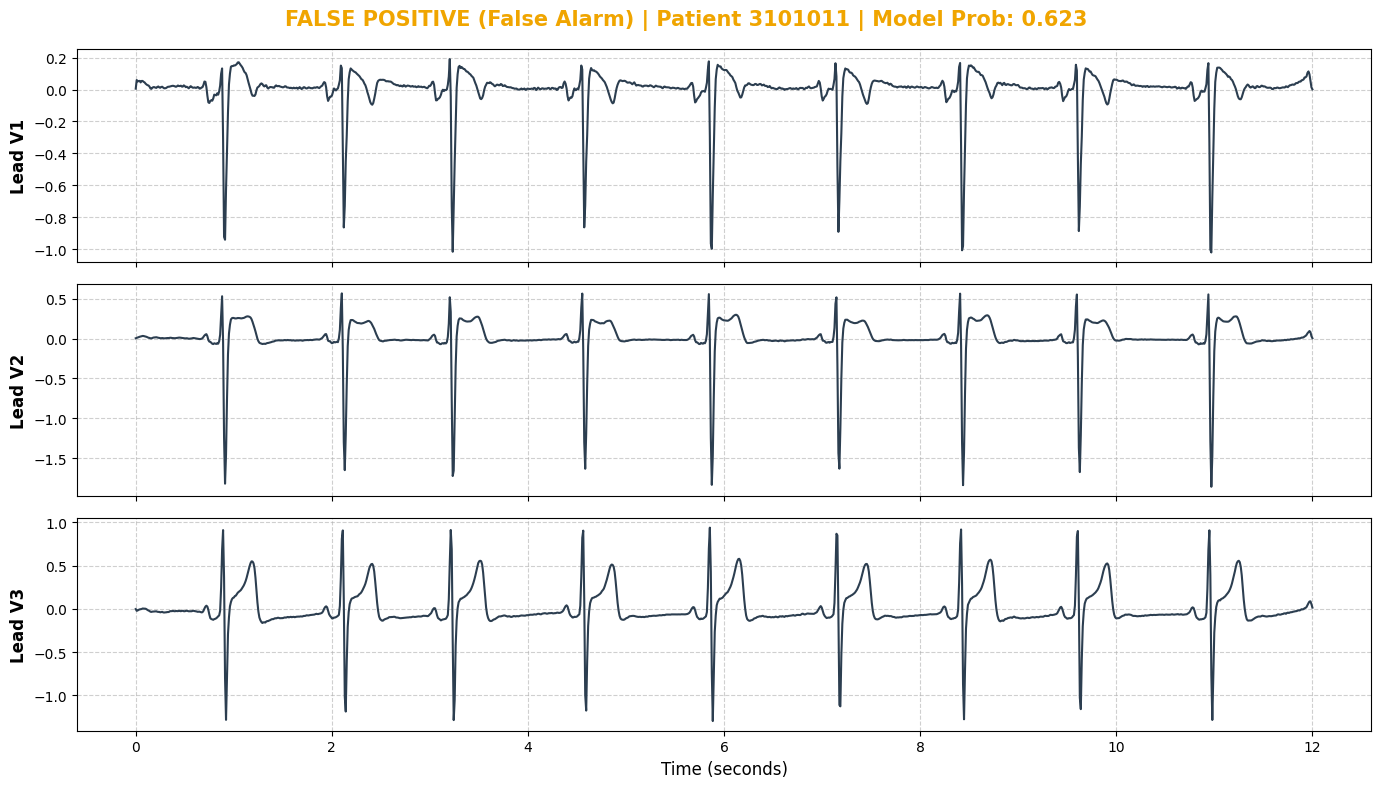

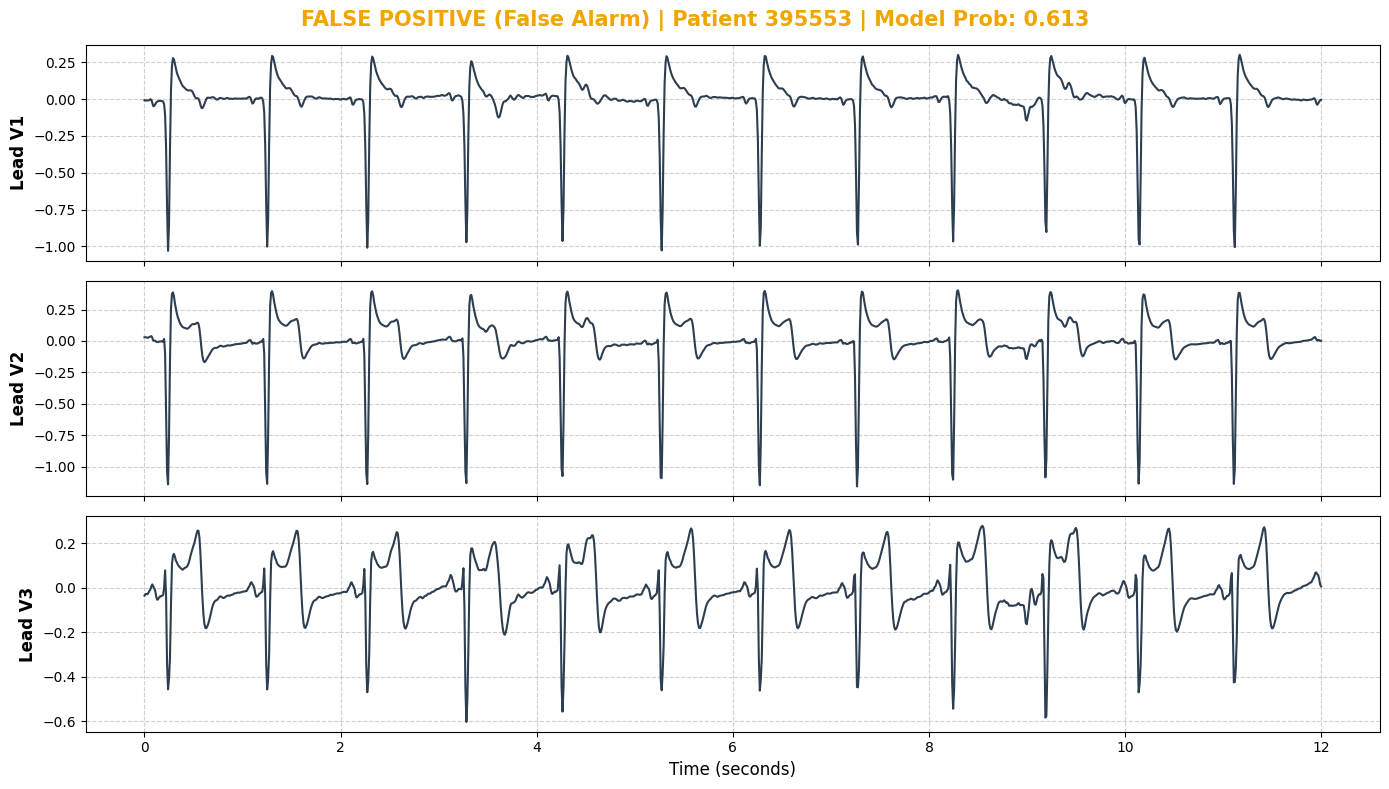

In [15]:
print("=" * 60)
print("ERROR ANALYSIS: MISCLASSIFIED PATIENTS")
print("=" * 60)

# 1. Identify False Negatives (Missed Brugada cases)
false_negatives = patient_df[(patient_df["y_true"] == 1) & (patient_df["y_pred"] == 0)].copy()
# Sort by lowest probability (the ones the model was most confidently wrong about)
false_negatives = false_negatives.sort_values(by="y_prob")

print(f"\n[ FALSE NEGATIVES ] - Total: {len(false_negatives)}")
print("Actual: Brugada | Predicted: Normal")
if not false_negatives.empty:
    for _, row in false_negatives.iterrows():
        print(f" -> Patient ID: {row['pid']} | Model Probability: {row['y_prob']:.3f} (Threshold: {optimal_threshold:.3f})")
else:
    print(" -> None! The model caught every Brugada patient.")

# 2. Identify False Positives (False Alarms)
false_positives = patient_df[(patient_df["y_true"] == 0) & (patient_df["y_pred"] == 1)].copy()
# Sort by highest probability (the ones the model was most confidently wrong about)
false_positives = false_positives.sort_values(by="y_prob", ascending=False)

print(f"\n[ FALSE POSITIVES ] - Total: {len(false_positives)}")
print("Actual: Normal | Predicted: Brugada")
if not false_positives.empty:
    for _, row in false_positives.iterrows():
        print(f" -> Patient ID: {row['pid']} | Model Probability: {row['y_prob']:.3f} (Threshold: {optimal_threshold:.3f})")
else:
    print(" -> None! The model had no false alarms.")

print("\n" + "=" * 60)

# -------------------------------------------------------------------
# VISUALIZATION: ECGs that confused the model
# -------------------------------------------------------------------

def plot_misclassified_patient(patient_id, true_label, predicted_prob):
    """
    Loads and plots the filtered 12-second ECG strip for a specific patient
    so to visually inspect why the model got it wrong.
    """
    # FIX: Force the patient_id to be an integer to remove the '.0'
    # then convert to string for the file path.
    clean_pid = str(int(patient_id))

    try:
        raw_ecg, original_fs = load_multilead(clean_pid)
        filtered_ecg, fs = preprocess(raw_ecg, original_fs)

        time_axis = np.linspace(0, len(filtered_ecg) / fs, len(filtered_ecg))

        fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
        title_type = "FALSE NEGATIVE (Missed Brugada)" if true_label == 1 else "FALSE POSITIVE (False Alarm)"
        color = "#E05C5C" if true_label == 1 else "#F0A500"

        fig.suptitle(f"{title_type} | Patient {clean_pid} | Model Prob: {predicted_prob:.3f}",
                     fontsize=15, fontweight='bold', color=color)

        # Plot V1, V2, and V3
        for i in range(3):
            ax = axes[i]
            ax.plot(time_axis, filtered_ecg[:, i], color='#2c3e50', linewidth=1.5)
            ax.set_ylabel(f"Lead {TARGET_LEADS[i]}", fontsize=12, fontweight='bold')
            ax.grid(True, linestyle='--', alpha=0.6)

        axes[-1].set_xlabel("Time (seconds)", fontsize=12)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Could not load/plot patient {clean_pid}. Error: {e}")

# 3. Plot the top 2 False Negatives and top 2 False Positives
print("\nGenerating ECG plots for the most confusing cases...\n")

if not false_negatives.empty:
    for _, row in false_negatives.head(2).iterrows():
        plot_misclassified_patient(row['pid'], row['y_true'], row['y_prob'])

if not false_positives.empty:
    for _, row in false_positives.head(2).iterrows():
        plot_misclassified_patient(row['pid'], row['y_true'], row['y_prob'])

### **2D CWT dataset**

In [16]:
print("=" * 50)
print("2D CWT SPECTROGRAM CONVERSION")
print("=" * 50)

def beat_to_scalogram(beat_1d, target_size=(224, 224)):
    """
    Converts a single (time_steps, 3) 1D beat into a (224, 224, 3) RGB Scalogram image.
    Lead V1 -> Red channel
    Lead V2 -> Green channel
    Lead V3 -> Blue channel
    """
    # Define the scales for the Morlet wavelet (controls the frequency resolution)
    # 1 to 64 covers the high-frequency and low-frequency components of the ECG well
    scales = np.arange(1, 64)
    wavelet = 'morl'

    img_channels = []

    # Process each lead independently
    for i in range(3):
        lead_signal = beat_1d[:, i]

        # 1. Apply Continuous Wavelet Transform
        coeffs, freqs = pywt.cwt(lead_signal, scales, wavelet)

        # 2. Get the magnitude (absolute value) of the complex coefficients
        magnitude = np.abs(coeffs)

        # 3. Resize to 224x224 (The standard input size for ResNet/EfficientNet)
        magnitude_resized = cv2.resize(magnitude, target_size, interpolation=cv2.INTER_CUBIC)

        # 4. Normalize to 0-255 so it functions exactly like pixel intensity
        min_val = np.min(magnitude_resized)
        max_val = np.max(magnitude_resized)

        if max_val - min_val == 0:
            normalized = np.zeros_like(magnitude_resized)
        else:
            normalized = 255 * (magnitude_resized - min_val) / (max_val - min_val)

        img_channels.append(normalized.astype(np.uint8))

    # Stack the 3 channels to create the final RGB image
    # Note: cv2 uses BGR by default, but we will explicitly stack as RGB for the model
    rgb_image = np.stack(img_channels, axis=-1)

    return rgb_image

# --- PROCESS THE ENTIRE DATASET ---
print("Transforming Training Data...")
# Using np.uint8 drastically saves RAM (1 Byte per pixel instead of 4 or 8)
X_train_img = np.zeros((len(X_train), 224, 224, 3), dtype=np.uint8)
for i in range(len(X_train)):
    X_train_img[i] = beat_to_scalogram(X_train[i])
    if (i+1) % 500 == 0:
        print(f" -> Processed {i+1}/{len(X_train)} beats")

print("\nTransforming Testing Data...")
X_test_img = np.zeros((len(X_test), 224, 224, 3), dtype=np.uint8)
for i in range(len(X_test)):
    X_test_img[i] = beat_to_scalogram(X_test[i])
    if (i+1) % 500 == 0:
        print(f" -> Processed {i+1}/{len(X_test)} beats")

# Split Validation from Training images (using the same indices from earlier)
print("\nTransforming Validation Data...")
X_val_img = np.zeros((len(X_val), 224, 224, 3), dtype=np.uint8)
for i in range(len(X_val)):
    X_val_img[i] = beat_to_scalogram(X_val[i])

print("\nConversion Complete!")
print(f"New Image Input Shape: {X_train_img.shape}")

2D CWT SPECTROGRAM CONVERSION
Transforming Training Data...
 -> Processed 500/3050 beats
 -> Processed 1000/3050 beats
 -> Processed 1500/3050 beats
 -> Processed 2000/3050 beats
 -> Processed 2500/3050 beats
 -> Processed 3000/3050 beats

Transforming Testing Data...
 -> Processed 500/955 beats

Transforming Validation Data...

Conversion Complete!
New Image Input Shape: (3050, 224, 224, 3)


### **Visualizing the Result**

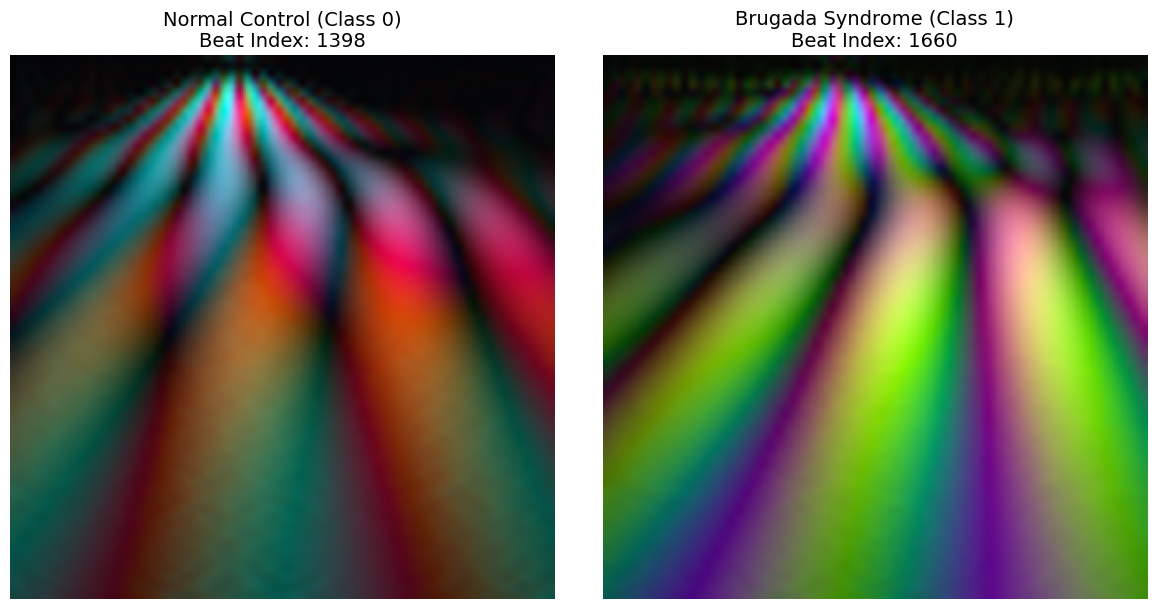

In [17]:
def plot_scalogram_comparison(X_images, y_labels):
    """
    Plots a random Normal scalogram vs a random Brugada scalogram side-by-side.
    """
    # Find one random index for each class
    normal_idx = np.where(y_labels == 0)[0][np.random.randint(0, sum(y_labels == 0))]
    brugada_idx = np.where(y_labels == 1)[0][np.random.randint(0, sum(y_labels == 1))]

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Plot Normal
    axes[0].imshow(X_images[normal_idx])
    axes[0].set_title(f"Normal Control (Class 0)\nBeat Index: {normal_idx}", fontsize=14)
    axes[0].axis('off')

    # Plot Brugada
    axes[1].imshow(X_images[brugada_idx])
    axes[1].set_title(f"Brugada Syndrome (Class 1)\nBeat Index: {brugada_idx}", fontsize=14)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# Run it a few times to see different examples
plot_scalogram_comparison(X_train_img, y_train)

### **Run Modelling**

PHASE 3: RESNET-50 TRANSFER LEARNING
Formatting images for ResNet50...
Model architecture compiled. Base ResNet50 layers are frozen.

Starting Training (Feature Extraction Phase)...
Epoch 1/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 40s 260ms/step - accuracy: 0.6508 - loss: 0.7311 - val_accuracy: 0.6658 - val_loss: 0.5547 - learning_rate: 0.0010
Epoch 2/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - accuracy: 0.7797 - loss: 0.4684 - val_accuracy: 0.7736 - val_loss: 0.4742 - learning_rate: 0.0010
Epoch 3/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - accuracy: 0.8502 - loss: 0.3700 - val_accuracy: 0.8396 - val_loss: 0.4210 - learning_rate: 0.0010
Epoch 4/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.8728 - loss: 0.3107 - val_accuracy: 0.8275 - val_loss: 0.4516 - learning_rate: 0.0010
Epoch 5/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.8830 - loss: 0.2910 - val_accuracy: 0.7857 - val_loss: 0.5041 - learning_rate: 0.0010
Epoch 6/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 110ms/step 

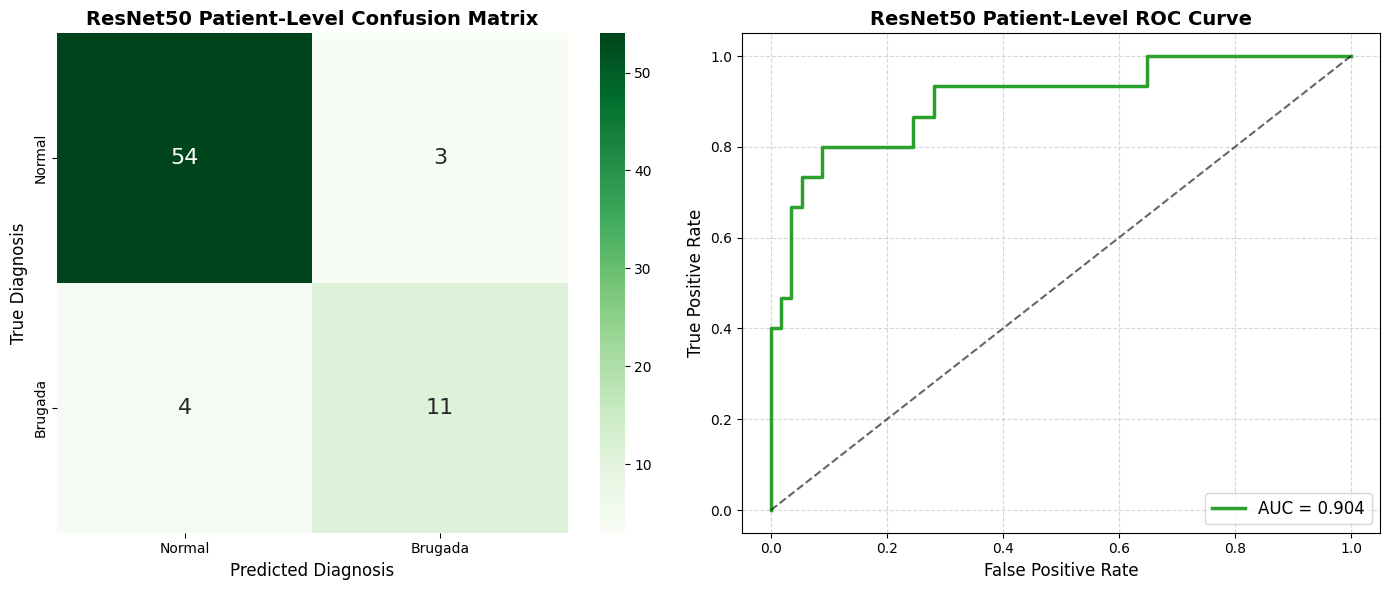

In [18]:
print("=" * 60)
print("PHASE 3: RESNET-50 TRANSFER LEARNING")
print("=" * 60)

# -------------------------------------------------------------------
# 1. DATA FORMATTING FOR RESNET
# ResNet50 expects images in a very specific mathematical format
# (BGR instead of RGB, and zero-centered based on ImageNet stats).
# -------------------------------------------------------------------
print("Formatting images for ResNet50...")
# Convert to float32 and apply ResNet's built-in preprocessing
X_train_resnet = preprocess_input(X_train_img.astype(np.float32))
X_val_resnet = preprocess_input(X_val_img.astype(np.float32))
X_test_resnet = preprocess_input(X_test_img.astype(np.float32))

# -------------------------------------------------------------------
# 2. BUILD THE TRANSFER LEARNING ARCHITECTURE
# -------------------------------------------------------------------
def build_resnet_transfer_model():
    # Load the pre-trained ResNet50 (without its original 1000-class classification head)
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    # FREEZE THE BASE: We don't want to destroy the pre-trained weights during initial training
    base_model.trainable = False

    # Build our custom classification head on top of ResNet
    inputs = tf.keras.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False) # Keep BatchNormalization layers in inference mode

    # Flatten the 2D features into a 1D vector
    x = layers.GlobalAveragePooling2D()(x)

    # Custom Dense layers to learn the Brugada-specific features
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x) # High dropout to prevent overfitting
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    # Binary classification output (Normal vs Brugada)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    return models.Model(inputs, outputs)

resnet_model = build_resnet_transfer_model()

# Use standard binary crossentropy here because class weights are passed
resnet_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

print("Model architecture compiled. Base ResNet50 layers are frozen.")

# -------------------------------------------------------------------
# 3. TRAINING
# -------------------------------------------------------------------
# Re-calculate class weights (just in case)
from sklearn.utils import class_weight
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = {0: weights[0], 1: weights[1]}

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
]

print("\nStarting Training (Feature Extraction Phase)...")
# Note: Batch size is set to 32.
history_resnet = resnet_model.fit(
    X_train_resnet, y_train,
    validation_data=(X_val_resnet, y_val),
    epochs=20, # 20 is usually enough for the frozen head to converge
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=callbacks
)

# -------------------------------------------------------------------
# 4. PATIENT-LEVEL CLINICAL EVALUATION
# -------------------------------------------------------------------
print("\nAggregating predictions to Patient-Level...")
y_prob_beats_resnet = resnet_model.predict(X_test_resnet, verbose=0).ravel()

# Group by Patient ID (re-using the groups_test array from earlier)
df_res = pd.DataFrame({"pid": groups_test, "y_true": y_test, "y_prob": y_prob_beats_resnet})
patient_df_res = df_res.groupby("pid").mean().reset_index()

# Find Optimal Threshold
precision, recall, thresholds = precision_recall_curve(patient_df_res["y_true"], patient_df_res["y_prob"])
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-8)
opt_thresh_res = thresholds[np.argmax(f1_scores)]

patient_df_res["y_pred"] = (patient_df_res["y_prob"] >= opt_thresh_res).astype(int)

print("\n" + "=" * 55)
print("RESNET-50 CLINICAL EVALUATION (PATIENT-LEVEL)")
print("=" * 55)
print(f"Optimal Decision Threshold: {opt_thresh_res:.3f}")
print(classification_report(patient_df_res["y_true"], patient_df_res["y_pred"], target_names=["Normal", "Brugada"]))

# --- PLOTTING ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion Matrix
sns.heatmap(confusion_matrix(patient_df_res["y_true"], patient_df_res["y_pred"]),
            annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=["Normal", "Brugada"], yticklabels=["Normal", "Brugada"],
            annot_kws={"size": 16})
axes[0].set_title("ResNet50 Patient-Level Confusion Matrix", fontsize=14, fontweight='bold')
axes[0].set_ylabel("True Diagnosis", fontsize=12)
axes[0].set_xlabel("Predicted Diagnosis", fontsize=12)

# ROC Curve
auc = roc_auc_score(patient_df_res["y_true"], patient_df_res["y_prob"])
fpr, tpr, _ = roc_curve(patient_df_res["y_true"], patient_df_res["y_prob"])
axes[1].plot(fpr, tpr, label=f"AUC = {auc:.3f}", color='#2ca02c', linewidth=2.5)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.6)
axes[1].set_title("ResNet50 Patient-Level ROC Curve", fontsize=14, fontweight='bold')
axes[1].set_xlabel("False Positive Rate", fontsize=12)
axes[1].set_ylabel("True Positive Rate", fontsize=12)
axes[1].legend(loc="lower right", fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### **Phase 2**

PHASE 4: RESNET-50 FINE-TUNING
Total layers in base model: 175
Unfrozen the top 30 layers for fine-tuning.

Starting Fine-Tuning Training...
Epoch 1/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 54s 335ms/step - accuracy: 0.8797 - loss: 0.3445 - val_accuracy: 0.7426 - val_loss: 0.5713 - learning_rate: 1.0000e-05
Epoch 2/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 148ms/step - accuracy: 0.9597 - loss: 0.1072 - val_accuracy: 0.8531 - val_loss: 0.4652 - learning_rate: 1.0000e-05
Epoch 3/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 150ms/step - accuracy: 0.9859 - loss: 0.0521 - val_accuracy: 0.8612 - val_loss: 0.4605 - learning_rate: 1.0000e-05
Epoch 4/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 150ms/step - accuracy: 0.9948 - loss: 0.0322 - val_accuracy: 0.8679 - val_loss: 0.5037 - learning_rate: 1.0000e-05
Epoch 5/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 15s 151ms/step - accuracy: 0.9977 - loss: 0.0192 - val_accuracy: 0.8544 - val_loss: 0.5398 - learning_rate: 1.0000e-05
Epoch 6/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 15s 152ms/step - accuracy: 0.9984 - 

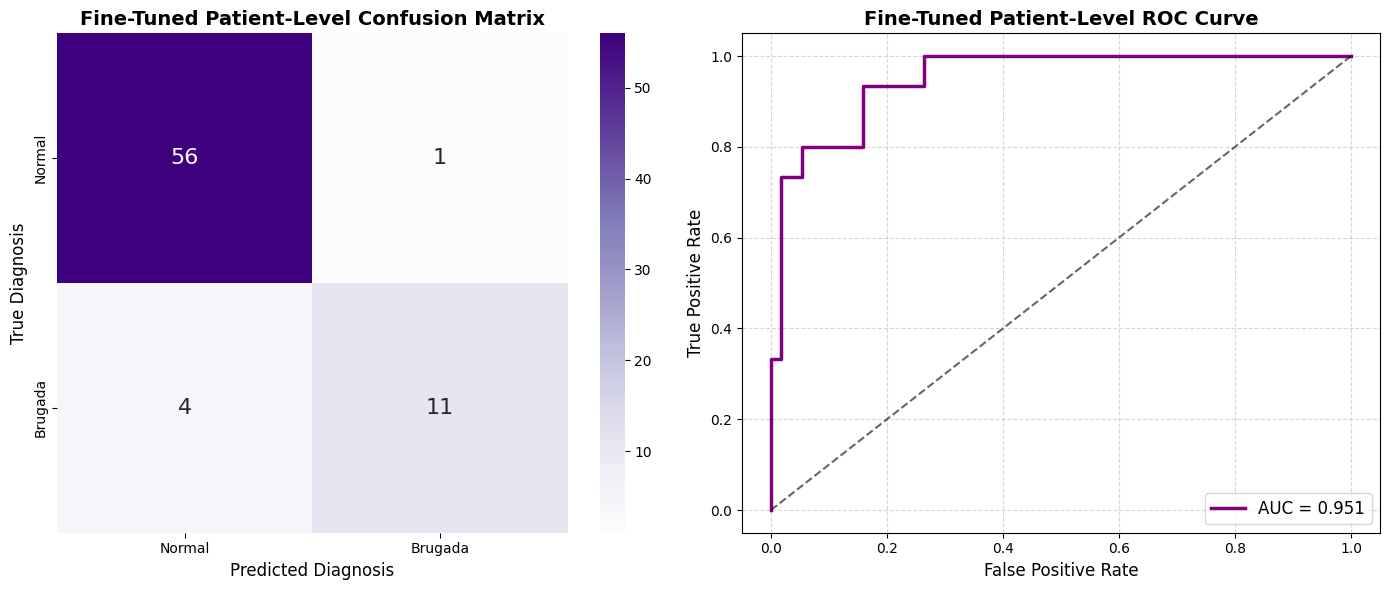

In [19]:
print("=" * 60)
print("PHASE 4: RESNET-50 FINE-TUNING")
print("=" * 60)

# 1. Extract the base ResNet50 model from our overall architecture
# (It is the second layer in our model, right after the Input layer)
base_model = resnet_model.layers[1]

# 2. Unfreeze the base model
base_model.trainable = True

# 3. Freeze all the bottom layers, but leave the top 30 layers UNfrozen.
# The bottom layers detect basic lines and curves (which we want to keep).
# The top layers detect complex, specific shapes (which we want to adapt to ECGs).
for layer in base_model.layers[:-30]:
    layer.trainable = False

print(f"Total layers in base model: {len(base_model.layers)}")
print("Unfrozen the top 30 layers for fine-tuning.")

# 4. Re-compile the model with a MICROSCOPIC learning rate
# This is critical. A standard learning rate will destroy the pre-trained weights.
resnet_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

# 5. Train the un-frozen model
callbacks_finetune = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
]

print("\nStarting Fine-Tuning Training...")
history_finetune = resnet_model.fit(
    X_train_resnet, y_train,
    validation_data=(X_val_resnet, y_val),
    epochs=20,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=callbacks_finetune
)

# -------------------------------------------------------------------
# 6. FINAL CLINICAL EVALUATION OF FINE-TUNED MODEL
# -------------------------------------------------------------------
print("\nAggregating Fine-Tuned predictions to Patient-Level...")
y_prob_beats_finetuned = resnet_model.predict(X_test_resnet, verbose=0).ravel()

df_ft = pd.DataFrame({"pid": groups_test, "y_true": y_test, "y_prob": y_prob_beats_finetuned})
patient_df_ft = df_ft.groupby("pid").mean().reset_index()

# Find Optimal Threshold
precision, recall, thresholds = precision_recall_curve(patient_df_ft["y_true"], patient_df_ft["y_prob"])
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-8)
opt_thresh_ft = thresholds[np.argmax(f1_scores)]

patient_df_ft["y_pred"] = (patient_df_ft["y_prob"] >= opt_thresh_ft).astype(int)

print("\n" + "=" * 55)
print("FINE-TUNED RESNET-50 CLINICAL EVALUATION")
print("=" * 55)
print(f"Optimal Decision Threshold: {opt_thresh_ft:.3f}")
print(classification_report(patient_df_ft["y_true"], patient_df_ft["y_pred"], target_names=["Normal", "Brugada"]))

# --- PLOTTING ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion Matrix
sns.heatmap(confusion_matrix(patient_df_ft["y_true"], patient_df_ft["y_pred"]),
            annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=["Normal", "Brugada"], yticklabels=["Normal", "Brugada"],
            annot_kws={"size": 16})
axes[0].set_title("Fine-Tuned Patient-Level Confusion Matrix", fontsize=14, fontweight='bold')
axes[0].set_ylabel("True Diagnosis", fontsize=12)
axes[0].set_xlabel("Predicted Diagnosis", fontsize=12)

# ROC Curve
auc = roc_auc_score(patient_df_ft["y_true"], patient_df_ft["y_prob"])
fpr, tpr, _ = roc_curve(patient_df_ft["y_true"], patient_df_ft["y_prob"])
axes[1].plot(fpr, tpr, label=f"AUC = {auc:.3f}", color='#800080', linewidth=2.5)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.6)
axes[1].set_title("Fine-Tuned Patient-Level ROC Curve", fontsize=14, fontweight='bold')
axes[1].set_xlabel("False Positive Rate", fontsize=12)
axes[1].set_ylabel("True Positive Rate", fontsize=12)
axes[1].legend(loc="lower right", fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

PHASE 5: MODEL INTERPRETABILITY (DEEP SHAP + ECG SEMANTICS)
Building Deep SHAP explainer...


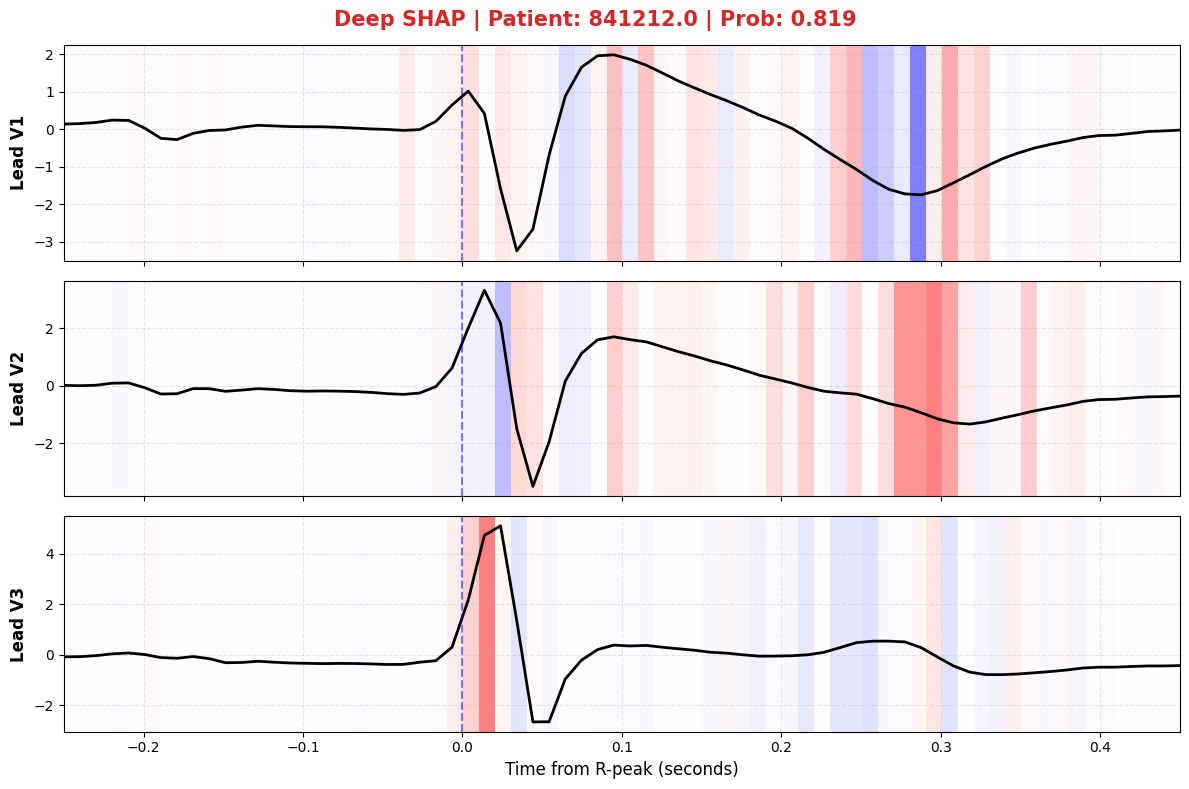


MODEL EXPLANATION | Brugada Prob: 0.819
T-wave         : 0.553
ST-segment     : 0.210
QRS-complex    : 0.203
PR-segment     : 0.018
P-wave         : 0.017

INTERPRETATION:
→ Model influenced by repolarization pattern.


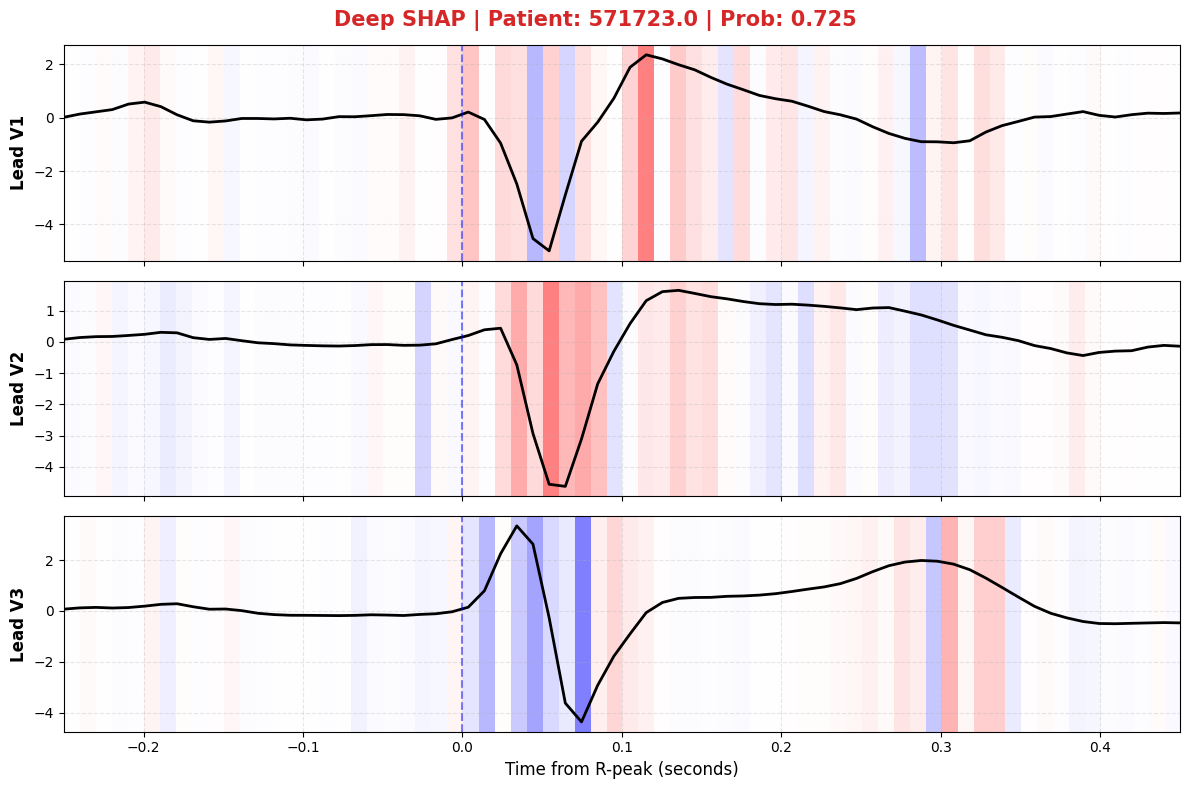


MODEL EXPLANATION | Brugada Prob: 0.725
ST-segment     : 0.487
T-wave         : 0.276
QRS-complex    : 0.150
P-wave         : 0.050
PR-segment     : 0.037

INTERPRETATION:
→ Model focuses on ST morphology (Brugada-relevant).


In [22]:
print("=" * 60)
print("PHASE 5: MODEL INTERPRETABILITY (DEEP SHAP + ECG SEMANTICS)")
print("=" * 60)

# =========================================================
# 1. BUILD EXPLAINER
# =========================================================
def build_deep_explainer(model, X_background):
    X_background = X_background.astype(np.float32)

    # Force inference mode globally (Keras 3 workaround)
    for layer in model.layers:
        if hasattr(layer, "training"):
            layer.training = False

    return shap.DeepExplainer(model, X_background)

# =========================================================
# 2. COMPUTE SHAP VALUES
# =========================================================
def compute_deep_shap_values(explainer, beat):
    beat = beat[np.newaxis, ...].astype(np.float32)

    shap_vals = explainer.shap_values(beat)

    # Binary classifier handling
    if isinstance(shap_vals, list):
        shap_vals = shap_vals[0]

    return shap_vals[0]  # (time, leads)

# =========================================================
# 3. ECG REGION SEGMENTATION (R-PEAK ALIGNED)
# =========================================================
def get_ecg_regions(time_axis):
    regions = {
        "P-wave": (-0.20, -0.08),
        "PR-segment": (-0.08, -0.02),
        "QRS-complex": (-0.02, 0.04),
        "ST-segment": (0.04, 0.20),
        "T-wave": (0.20, 0.40)
    }

    region_masks = {}
    for name, (start, end) in regions.items():
        mask = (time_axis >= start) & (time_axis <= end)
        region_masks[name] = mask

    return region_masks

# =========================================================
# 4. SUMMARIZE SHAP BY ECG REGION
# =========================================================
def summarize_shap_by_region(shap_values, time_axis):
    region_masks = get_ecg_regions(time_axis)

    summary = {}
    for region, mask in region_masks.items():
        contribution = np.sum(np.abs(shap_values[mask]))
        summary[region] = contribution

    total = sum(summary.values()) + 1e-8
    summary = {k: v / total for k, v in summary.items()}

    return summary

# =========================================================
# 5. HUMAN-READABLE EXPLANATION
# =========================================================
def explain_prediction(shap_values, beat, prob):
    time_axis = np.linspace(-0.25, 0.45, len(beat))
    summary = summarize_shap_by_region(shap_values, time_axis)

    print("\n" + "="*50)
    print(f"MODEL EXPLANATION | Brugada Prob: {prob:.3f}")
    print("="*50)

    sorted_regions = sorted(summary.items(), key=lambda x: x[1], reverse=True)

    for region, value in sorted_regions:
        print(f"{region:15s}: {value:.3f}")

    top_region = sorted_regions[0][0]

    print("\nINTERPRETATION:")

    if top_region == "ST-segment":
        print("→ Model focuses on ST morphology (Brugada-relevant).")
    elif top_region == "QRS-complex":
        print("→ Model uses depolarization shape (conduction abnormality).")
    elif top_region == "T-wave":
        print("→ Model influenced by repolarization pattern.")
    else:
        print("→ Model relies on atypical regions — verify signal quality.")

# =========================================================
# 6. VISUALIZATION
# =========================================================
def plot_shap_1d(beat, shap_values, patient_id, prob):
    time_axis = np.linspace(-0.25, 0.45, len(beat))

    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    fig.suptitle(f"Deep SHAP | Patient: {patient_id} | Prob: {prob:.3f}",
                 fontsize=15, fontweight='bold', color='#d62728')

    for i in range(3):
        ax = axes[i]

        signal = beat[:, i]
        shap_signal = shap_values[:, i]

        ax.plot(time_axis, signal, color='black', linewidth=2)
        ax.set_ylabel(f"Lead {TARGET_LEADS[i]}", fontsize=12, fontweight='bold')
        ax.axvline(0, color='blue', linestyle='--', alpha=0.5)

        norm = np.max(np.abs(shap_signal)) + 1e-8
        norm_shap = shap_signal / norm

        extent = [time_axis[0], time_axis[-1], ax.get_ylim()[0], ax.get_ylim()[1]]
        ax.imshow(norm_shap[np.newaxis, :],
                  cmap='bwr',
                  aspect='auto',
                  extent=extent,
                  alpha=0.5,
                  vmin=-1, vmax=1)

        ax.grid(True, linestyle='--', alpha=0.3)

    axes[-1].set_xlabel("Time from R-peak (seconds)", fontsize=12)
    plt.tight_layout()
    plt.show()

# =========================================================
# 7. EXECUTION PIPELINE
# =========================================================
true_positives = patient_df[
    (patient_df["y_true"] == 1) & (patient_df["y_pred"] == 1)
].sort_values(by="y_prob", ascending=False)

if not true_positives.empty:
    print("Building Deep SHAP explainer...")

    background = X_test[
        np.random.choice(len(X_test), size=100, replace=False)
    ]

    explainer = build_deep_explainer(model, background)

    for _, row in true_positives.head(2).iterrows():
        pid = row['pid']

        patient_beat_indices = np.where(groups_test == pid)[0]

        if len(patient_beat_indices) > 0:
            beat_idx = patient_beat_indices[0]
            beat_data = X_test[beat_idx]

            shap_vals = compute_deep_shap_values(explainer, beat_data)

            plot_shap_1d(beat_data, shap_vals, pid, row['y_prob'])
            explain_prediction(shap_vals, beat_data, row['y_prob'])

else:
    print("No True Positives found to visualize.")